<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter16_Singular_Value_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 16 — Singular Value Decomposition (SVD)

## Tujuan Chapter

Pada chapter ini kita mempelajari:

1. Singular Value Decomposition (SVD)
2. Singular Values
3. Left Singular Vectors
4. Right Singular Vectors
5. Full SVD
6. Reduced SVD
7. Matrix Rank
8. Low Rank Approximation
9. Hubungan SVD dan Eigenvalue
10. Pengantar PCA

SVD merupakan salah satu metode paling penting dalam:

- Machine Learning
- Data Science
- Computer Vision
- Signal Processing
- Recommendation Systems

# Ringkasan Teori

SVD memecah matriks:

\[
A
\]

menjadi:

\[
A = U \Sigma V^T
\]

dimana:

- U = left singular vectors
- Σ = singular values
- V = right singular vectors

SVD selalu dapat dilakukan pada matriks apa pun.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(
    precision=4,
    suppress=True
)

# 1. Membuat Matriks Contoh

In [2]:
A = np.array([
    [3,2,2],
    [2,3,-2]
])

print(A)

[[ 3  2  2]
 [ 2  3 -2]]


# Bentuk Matriks

Ukuran matriks:

\[
m \times n
\]

In [3]:
print(A.shape)

(2, 3)


# 2. Menghitung SVD

NumPy menyediakan:

```python
np.linalg.svd()
```

In [4]:
U,S,VT = np.linalg.svd(A)

print("U =")
print(U)

print("\nS =")
print(S)

print("\nVT =")
print(VT)

U =
[[-0.7071 -0.7071]
 [-0.7071  0.7071]]

S =
[5. 3.]

VT =
[[-0.7071 -0.7071 -0.    ]
 [-0.2357  0.2357 -0.9428]
 [-0.6667  0.6667  0.3333]]


# Interpretasi Output

U berisi left singular vectors.

S berisi singular values.

VT berisi transpose dari right singular vectors.

# 3. Matriks Sigma

In [5]:
Sigma = np.zeros((2,3))

Sigma[0,0] = S[0]
Sigma[1,1] = S[1]

print(Sigma)

[[5. 0. 0.]
 [0. 3. 0.]]


# 4. Rekonstruksi Matriks

Verifikasi:

\[
A=U\Sigma V^T
\]

In [6]:
A_reconstructed = U @ Sigma @ VT

print(A_reconstructed)

[[ 3.  2.  2.]
 [ 2.  3. -2.]]


# Verifikasi

In [7]:
np.allclose(
    A,
    A_reconstructed
)

True

# Hasil

Nilai True menunjukkan dekomposisi berhasil.

# 5. Singular Values

In [8]:
print(S)

[5. 3.]


# Interpretasi

Semakin besar singular value, semakin besar informasi yang dikandung komponen tersebut.

# 6. Visualisasi Singular Values

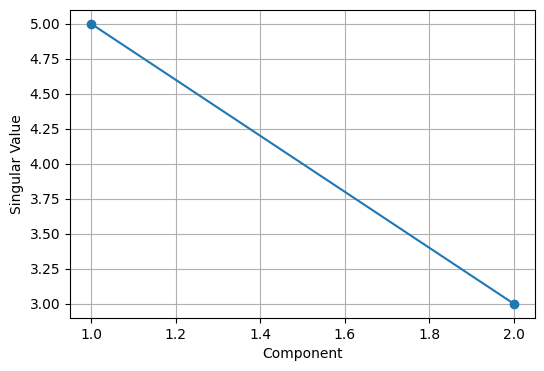

In [9]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1,len(S)+1),
    S,
    marker='o'
)

plt.xlabel("Component")
plt.ylabel("Singular Value")

plt.grid(True)
plt.show()

# 7. Hubungan dengan Eigenvalue

Singular values berasal dari:

\[
A^TA
\]

In [10]:
ATA = A.T @ A

print(ATA)

[[13 12  2]
 [12 13 -2]
 [ 2 -2  8]]


In [11]:
eigvals, eigvecs = np.linalg.eig(ATA)

print(eigvals)

[25.  0.  9.]


# Menghitung Singular Values dari Eigenvalue

In [12]:
np.sqrt(
    np.abs(eigvals)
)

array([5., 0., 3.])

# Perbandingan

In [13]:
print("Singular Values:")
print(S)

Singular Values:
[5. 3.]


# 8. Matrix Rank

Rank menunjukkan jumlah singular value yang tidak nol.

In [14]:
rank = np.linalg.matrix_rank(A)

print(rank)

2


# 9. Reduced SVD

In [15]:
U,S,VT = np.linalg.svd(
    A,
    full_matrices=False
)

print(U.shape)
print(S.shape)
print(VT.shape)

(2, 2)
(2,)
(2, 3)


# Reduced SVD

Reduced SVD lebih efisien dibanding Full SVD.

# 10. Low Rank Approximation

Kita hanya menyimpan singular value terbesar.

In [16]:
k = 1

Uk = U[:,:k]

Sk = np.diag(S[:k])

VTk = VT[:k,:]

In [17]:
A_lowrank = (
    Uk @
    Sk @
    VTk
)

print(A_lowrank)

[[2.5 2.5 0. ]
 [2.5 2.5 0. ]]


# Error Approximation

In [18]:
error = np.linalg.norm(
    A - A_lowrank
)

print(error)

3.0


# Interpretasi

Semakin banyak singular value yang disimpan, semakin kecil error.

# 11. Contoh Dataset PCA

In [19]:
X = np.array([
    [2,1],
    [3,2],
    [4,3],
    [5,4],
    [6,5]
])

print(X)

[[2 1]
 [3 2]
 [4 3]
 [5 4]
 [6 5]]


# Centering Data

In [20]:
X_centered = (
    X -
    np.mean(X,axis=0)
)

print(X_centered)

[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]


In [21]:
U,S,VT = np.linalg.svd(
    X_centered,
    full_matrices=False
)

print(S)

[4.4721 0.    ]


# Principal Component Pertama

In [22]:
pc1 = VT[0]

print(pc1)

[0.7071 0.7071]


In [23]:
projection = X_centered @ pc1

print(projection)

[-2.8284 -1.4142  0.      1.4142  2.8284]


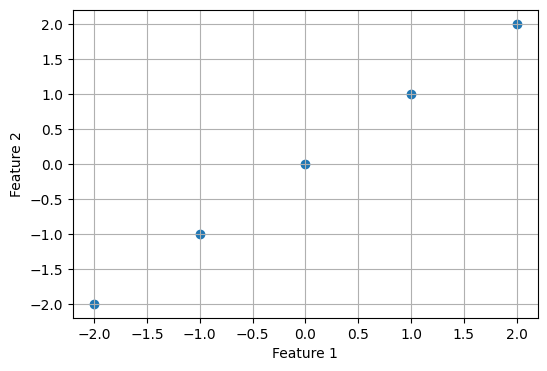

In [24]:
plt.figure(figsize=(6,4))

plt.scatter(
    X_centered[:,0],
    X_centered[:,1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.grid(True)
plt.show()

# Ringkasan Chapter 16

Pada chapter ini dipelajari:

- Singular Value Decomposition
- Singular Values
- Matrix Rank
- Reduced SVD
- Low Rank Approximation
- Hubungan SVD dan Eigenvalue
- Pengantar PCA

SVD merupakan salah satu algoritma paling penting dalam linear algebra modern dan menjadi dasar berbagai metode machine learning.